# **$AI^{2}$ $Mart$ Customer Behavior Analysis (2016): RFM Segmentation and CV-Based Purchasing Behavior**



# Customer Purchasing Behavior Analysis  
### AI² Mart – Jakarta (2016)

---

## Business Context
The dataset contains all customer transactions of **AI² Mart** in 2016 in Jakarta.  
The company wants to better understand **customer purchasing behavior** in order to design **more targeted and effective marketing strategies**.

---

## Stakeholders
The main stakeholders for this analysis are:

- **Management Team** – responsible for strategic decision making.
- **Business & Marketing Team** – responsible for designing customer retention and marketing campaigns based on customer segmentation insights.

---

## Problem Statements
Currently, the company faces several challenges:

1. Difficulty in understanding **customer purchasing behavior patterns**.
2. Difficulty in identifying **the most effective marketing campaign** for different customer segments.

---

## The Goal
The objective of this analysis is to:

- Segment customers based on their **transaction behavior** using **RFM Analysis**.
- Understand **customer purchasing consistency** using the **Coefficient of Variance (CV)**.
- Combine both approaches to uncover **customer personality patterns**.
- Provide **actionable marketing strategies** for each customer segment.

---

## Analytical Approach

> ### Data Preparation
1. Import the dataset.
2. Perform data cleaning and preprocessing.


> ### RFM Analysis

1. Calculate **Recency, Frequency, and Monetary values**.
2. Generate **RFM scores** for each customer.
3. Create **11 customer segments** based on RFM scores.
4. Visualize the distribution of customers across segments.

> ### Customer Purchasing Behavior (Coefficient of Variance)

1. Calculate the CV based on the number of customer transactions.
2. Categorizing the customers into 3 categories:
    - Stable
    - Normal
    - Impulsive

> ### Merging RFM and CV

1. Merge **RFM Segmentation** with **CV Behavior Categories**.
2. Analyze how **purchasing behavior varies within each RFM segment**.
3. Visualize the relationship using a **stacked bar plot**.

---

## 6. Customer Behavior Analysis Framework

The overall framework used in this analysis can be summarized as:

**RFM Analysis → Customer Segmentation → Behavior Variability (CV) → Customer Personality → Marketing Campaign Strategy**

### **Data Set Overview**
- ``Customer_ID`` : A unique identifier assigned for each customer.
- ``Date`` : The date when the customer transaction occured.
- ``Transaction_ID`` : A unique identifier for each transaction.
- ``SKU_Category`` : The category classification of the product based on the **Stock Keeping Unit (SKU)** system.
- ``SKU`` : **Stock Keeping Unit** — A unique product code assigned to each specific product.
- ``Quantity``: The number of units purchased for a specific SKU within a transaction.
- ``Sales_Amount`` : The total monetary value generated from the transaction.

# **RFM Analisis**

### **What is RFM?**

**RFM** stands for :
- **Recency** : How recently the customer made a purchase.
- **Frequency** : How often a customer makes purchases.
- **Monetary** : How much money a customer spends.

The **goal of RFM analysis** is to segment customers into predefined category based on the three values mentioned above.



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime
import datetime as dt

pd.set_option('display.max_rows',100)

## **1. Import Data**

In [ ]:
df=pd.read_csv('scanner_data.csv',parse_dates=['Date'], dayfirst=True).drop('Unnamed: 0',axis=1)
df.drop_duplicates(inplace=True)
df.sort_values('Customer_ID')

,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount
7284,2016-01-22,1,3442,0H2,6OUVC,1.0,10.50
7285,2016-01-22,1,3442,N8U,CEBU8,1.0,5.79
29172,2016-03-24,2,14177,TVL,2SLS0,1.0,7.77
61444,2016-06-19,2,30451,F9B,GZ6VU,1.0,15.00
156,2016-01-02,3,90,TW8,WALAE,1.0,1.38
...,...,...,...,...,...,...,...
128201,2016-12-31,22625,64664,0KX,6MN0P,1.0,1.11
123611,2016-12-19,22625,62553,1L6,Y2U6K,1.0,8.97
120926,2016-12-14,22625,61419,N8U,L61A1,1.0,2.33
115245,2016-12-02,22625,59000,N8U,61L0Q,1.0,2.73


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131706 entries, 0 to 131705
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Date            131706 non-null  datetime64[ns]
 1   Customer_ID     131706 non-null  int64         
 2   Transaction_ID  131706 non-null  int64         
 3   SKU_Category    131706 non-null  object        
 4   SKU             131706 non-null  object        
 5   Quantity        131706 non-null  float64       
 6   Sales_Amount    131706 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 7.0+ MB


In [ ]:
df.describe()

,Date,Customer_ID,Transaction_ID,Quantity,Sales_Amount
count,131706,131706.000000,131706.000000,131706.000000,131706.000000
mean,2016-07-04 18:00:03.608036096,12386.450367,32389.604187,1.485311,11.981524
min,2016-01-02 00:00:00,1.000000,1.000000,0.010000,0.020000
25%,2016-04-05 00:00:00,7349.000000,16134.000000,1.000000,4.230000
50%,2016-07-02 00:00:00,13496.000000,32620.000000,1.000000,6.920000
75%,2016-10-07 00:00:00,17306.000000,48548.000000,1.000000,12.330000
max,2016-12-31 00:00:00,22625.000000,64682.000000,400.000000,707.730000
std,NaN,6086.447552,18709.901238,3.872667,19.359699


## **2. Define Each RFM Metric**

## _**Recency**_

In [ ]:
### Define Observation Time
obs_time=df['Date'].max()+dt.timedelta(days=1)
obs_time

Timestamp('2017-01-01 00:00:00')

In [ ]:
# Define Last Transaction
last_tran=df.groupby('Customer_ID')['Date'].transform(max)

# Calculating Recency
df['Recency']=(obs_time-last_tran).dt.days
df


,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,Recency
0,2016-01-02,2547,1,X52,0EM7L,1.0,3.13,260
1,2016-01-02,822,2,2ML,68BRQ,1.0,5.46,333
2,2016-01-02,3686,3,0H2,CZUZX,1.0,6.35,299
3,2016-01-02,3719,4,0H2,549KK,1.0,5.59,302
4,2016-01-02,9200,5,0H2,K8EHH,1.0,6.88,267
...,...,...,...,...,...,...,...,...
131701,2016-07-04,20203,32900,IEV,FO112,3.0,6.46,58
131702,2016-07-04,20203,32900,N8U,I36F2,1.0,4.50,58
131703,2016-07-04,20203,32900,U5F,4X8P4,1.0,5.19,58
131704,2016-07-04,20203,32900,0H2,ZVTO4,1.0,4.57,58


## _**Frequency**_

In [ ]:
## Calculating frequency
df['Frequency']=df.groupby('Customer_ID')['Transaction_ID'].transform('nunique')
df

,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,Recency,Frequency
0,2016-01-02,2547,1,X52,0EM7L,1.0,3.13,260,7
1,2016-01-02,822,2,2ML,68BRQ,1.0,5.46,333,3
2,2016-01-02,3686,3,0H2,CZUZX,1.0,6.35,299,15
3,2016-01-02,3719,4,0H2,549KK,1.0,5.59,302,10
4,2016-01-02,9200,5,0H2,K8EHH,1.0,6.88,267,2
...,...,...,...,...,...,...,...,...,...
131701,2016-07-04,20203,32900,IEV,FO112,3.0,6.46,58,9
131702,2016-07-04,20203,32900,N8U,I36F2,1.0,4.50,58,9
131703,2016-07-04,20203,32900,U5F,4X8P4,1.0,5.19,58,9
131704,2016-07-04,20203,32900,0H2,ZVTO4,1.0,4.57,58,9


## _**Monetary**_

In [ ]:
df['Monetary'] = df.groupby('Customer_ID')['Sales_Amount'].transform('sum')
df

,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,Recency,Frequency,Monetary
0,2016-01-02,2547,1,X52,0EM7L,1.0,3.13,260,7,121.36
1,2016-01-02,822,2,2ML,68BRQ,1.0,5.46,333,3,20.40
2,2016-01-02,3686,3,0H2,CZUZX,1.0,6.35,299,15,405.44
3,2016-01-02,3719,4,0H2,549KK,1.0,5.59,302,10,420.72
4,2016-01-02,9200,5,0H2,K8EHH,1.0,6.88,267,2,18.01
...,...,...,...,...,...,...,...,...,...,...
131701,2016-07-04,20203,32900,IEV,FO112,3.0,6.46,58,9,270.60
131702,2016-07-04,20203,32900,N8U,I36F2,1.0,4.50,58,9,270.60
131703,2016-07-04,20203,32900,U5F,4X8P4,1.0,5.19,58,9,270.60
131704,2016-07-04,20203,32900,0H2,ZVTO4,1.0,4.57,58,9,270.60


## **3. Filtering the Data**

In [ ]:
df_rfm = df[['Customer_ID', 'Recency', 'Frequency', 'Monetary']]
df_rfm

,Customer_ID,Recency,Frequency,Monetary
0,2547,260,7,121.36
1,822,333,3,20.40
2,3686,299,15,405.44
3,3719,302,10,420.72
4,9200,267,2,18.01
...,...,...,...,...
131701,20203,58,9,270.60
131702,20203,58,9,270.60
131703,20203,58,9,270.60
131704,20203,58,9,270.60


## **4. RFM Score**

### _**RFM Scoring**_
Each RFM metric is assigned a score from **1 to 5**. The scores are calculated using quantile with _**``pd.qcut``**_.

In [ ]:

df_rfm['r_score']=pd.qcut(df_rfm['Recency'],5,labels=[5,4,3,2,1])
df_rfm['f_score']=pd.qcut(df_rfm['Frequency'],5,labels=[1,2,3,4,5])
df_rfm['m_score']=pd.qcut(df_rfm['Monetary'],5,labels=[1,2,3,4,5])
df_rfm

,Customer_ID,Recency,Frequency,Monetary,r_score,f_score,m_score
0,2547,260,7,121.36,1,3,3
1,822,333,3,20.40,1,2,1
2,3686,299,15,405.44,1,5,4
3,3719,302,10,420.72,1,4,4
4,9200,267,2,18.01,1,1,1
...,...,...,...,...,...,...,...
131701,20203,58,9,270.60,3,4,4
131702,20203,58,9,270.60,3,4,4
131703,20203,58,9,270.60,3,4,4
131704,20203,58,9,270.60,3,4,4


### _**Combine RFM Scores**_

In [ ]:
df_rfm['rfm_score']=df_rfm['r_score'].astype(str)+df_rfm['f_score'].astype(str)+df_rfm['m_score'].astype(str)
df_rfm

,Customer_ID,Recency,Frequency,Monetary,r_score,f_score,m_score,rfm_score
0,2547,260,7,121.36,1,3,3,133
1,822,333,3,20.40,1,2,1,121
2,3686,299,15,405.44,1,5,4,154
3,3719,302,10,420.72,1,4,4,144
4,9200,267,2,18.01,1,1,1,111
...,...,...,...,...,...,...,...,...
131701,20203,58,9,270.60,3,4,4,344
131702,20203,58,9,270.60,3,4,4,344
131703,20203,58,9,270.60,3,4,4,344
131704,20203,58,9,270.60,3,4,4,344


<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;500;600;700&display=swap');

body,
div,
h1,
h2,
h3,
h4,
h5,
h6,
p,
span,
label,
input,
textarea,
button,
pre,
code,
kbd,
samp {
    font-family: 'Poppins', sans-serif !important;
}
</style>
## **5. RFM Segmentation**

In this step, the combined RFM scores are used to segment customers into different groups. Each segment represents a different type of customer behaviors based on **recency, frequency, and monetary value**.

Below are the common segments used in RFM analysis:

- **Champion**: Customers who purchase frequently, recently made a purchase, and spends lots of money.
- **Loyal Customer**: Customers who purchase frequently and have high monetary value but may not always have the highest spending.
- **Potential Loyalist**: Customers who are almost but not fully loyal, possibly with a high frequency but still medium monetary value.
- **New Customers**: Customers who have just made their first purchase and may still be exploring the product or brand.
- **Promising**: New customers who have the potential to become loyal or high-value customers but have not yet made frequent transactions.
- **Need Attention**: Customers with good potential who need more attention and engagement to boost their activity.
- **Cannot Lose Them**: Customers with high monetary value but low purchase frequency. The customers may have not made a purchase for a long time and may need a special attention to prevent them from being inactive.
- **About to Sleep**: Customers with moderate recency and frequency who might stop transacting if not reactivated.
- **At Risk**:  Previously active customers who have not made a purchase for a while, indicating potential churn or loss.
- **Hibernating**: Customers who have not made a purchase in a long time and with low frequency and monetary value.
- **Lost**: Customers who have not purchased in a long time, with low frequency and monetary value, and are likely to be lost or churn.

In [ ]:
# Create customer segments based on RFM score
Champion = [555, 554, 544, 545, 454, 455, 445]
Loyal_Customer = [543, 444, 435, 355, 354, 345, 344, 335]
Potential_Loyalist = [553, 551, 552, 541, 542, 533, 532, 531, 452, 451, 442, 441, 431, 453, 433, 432, 423, 353, 352, 351, 342, 341, 333, 323]
New_Customer = [512, 511, 422, 421, 412, 411, 311]
Promising = [525, 524, 523, 522, 521, 515, 514, 513, 425,424, 413,414,415, 315, 314, 313]
Need_Attention = [535, 534, 443, 434, 343, 334, 325, 324]
Cannot_Lose_Them = [155, 154, 144, 214,215,115, 114, 113]
About_to_Sleep = [331, 321, 312, 221, 213]
At_Risk = [255, 254, 245, 244, 253, 252, 243, 242, 235, 234, 225, 224, 153, 152, 145, 143, 142, 135, 134, 133, 125, 124]
Hibernating = [332, 322, 231, 241, 251, 233, 232, 223, 222, 132, 123, 122, 212, 211]
Lost = [111, 112, 121, 131, 141, 151]

# Create a function to assign customers to various customer segments based on RFM score
def assign_cust_seg(col):
    list_col = list(col)
    segment = list()
    for score in list_col:
        if score in Champion:
            value = 'Champion'
        elif score in Loyal_Customer:
            value = 'Loyal Customer'
        elif score in Potential_Loyalist:
            value = 'Potential Loyalist'
        elif score in New_Customer:
            value = 'New Customer'
        elif score in Promising:
            value = 'Promising'
        elif score in Need_Attention:
            value = 'Need Attention'
        elif score in Cannot_Lose_Them:
            value = 'Cannot Lose Them'
        elif score in About_to_Sleep:
            value = 'About to Sleep'
        elif score in At_Risk:
            value = 'At Risk'
        elif score in Hibernating:
            value = 'Hibernating'
        elif score in Lost:
            value = 'Lost'
        else:
            value = 'null'
        segment.append(value)
    return segment

# Assign customers to segments based on their RFM score
df_rfm['Customer_Segment'] = assign_cust_seg(df_rfm['rfm_score'].astype(int))
df_rfm

,Customer_ID,Recency,Frequency,Monetary,r_score,f_score,m_score,rfm_score,Customer_Segment
0,2547,260,7,121.36,1,3,3,133,At Risk
1,822,333,3,20.40,1,2,1,121,Lost
2,3686,299,15,405.44,1,5,4,154,Cannot Lose Them
3,3719,302,10,420.72,1,4,4,144,Cannot Lose Them
4,9200,267,2,18.01,1,1,1,111,Lost
...,...,...,...,...,...,...,...,...,...
131701,20203,58,9,270.60,3,4,4,344,Loyal Customer
131702,20203,58,9,270.60,3,4,4,344,Loyal Customer
131703,20203,58,9,270.60,3,4,4,344,Loyal Customer
131704,20203,58,9,270.60,3,4,4,344,Loyal Customer


In [ ]:
df_rfm.drop_duplicates(inplace=True)

In [ ]:
pd.DataFrame(df_rfm['Customer_Segment'].value_counts())

,count
Customer_Segment,
Hibernating,7478
Lost,5560
New Customer,4129
About to Sleep,1140
Potential Loyalist,1055
At Risk,668
Champion,601
Promising,576
Loyal Customer,501


<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;500;600;700&display=swap');

body,
div,
h1,
h2,
h3,
h4,
h5,
h6,
p,
span,
label,
input,
textarea,
button,
pre,
code,
kbd,
samp {
    font-family: 'Poppins', sans-serif !important;
}
</style>
## **6. Analyze the Segments**

After segmenting customers, each segment is analyzed to understand their behavior:
- **Recency**: How recently customers in each segment made a purchase.
- **Frequency**: How often customers in each segment make purchases.
- **Monetary**: How much customers in each segment spend.

The analysis provides insights regarding:
- High-value customers who should be retained.
- Customers at risk of churn.
- Customers with growth potential.

This will help the **$AI^{2}$ $Mart$** to tailor their marketing strategies to be more targeted and effective.

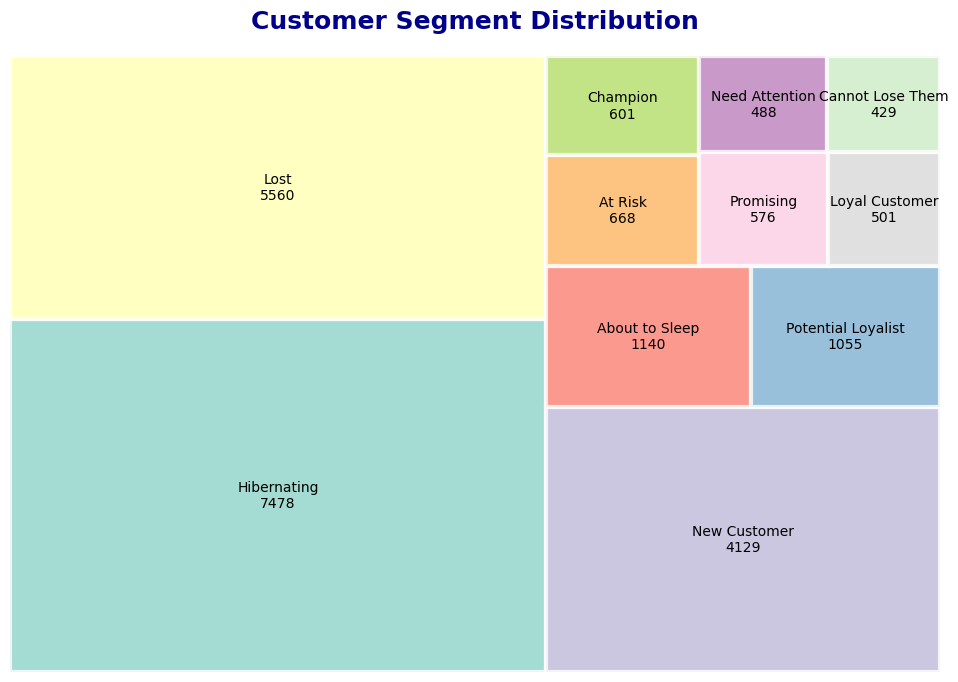

In [ ]:
import squarify
import matplotlib.pyplot as plt
import seaborn as sns

segment_counts = df_rfm['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Customer_Segment', 'count']

colors = sns.color_palette('Set3', len(segment_counts))

plt.figure(figsize=(12, 8))
squarify.plot(
    sizes=segment_counts['count'],
    label=segment_counts['Customer_Segment']+'\n'+segment_counts['count'].astype(str),
    color=colors,
    alpha=0.8,
    edgecolor='white',
    linewidth=3
)

plt.axis('off')

plt.title(
    'Customer Segment Distribution',
    fontsize=18,
    fontweight='bold',
    color='darkblue',
    pad=20
)

# Display the plot
plt.show()

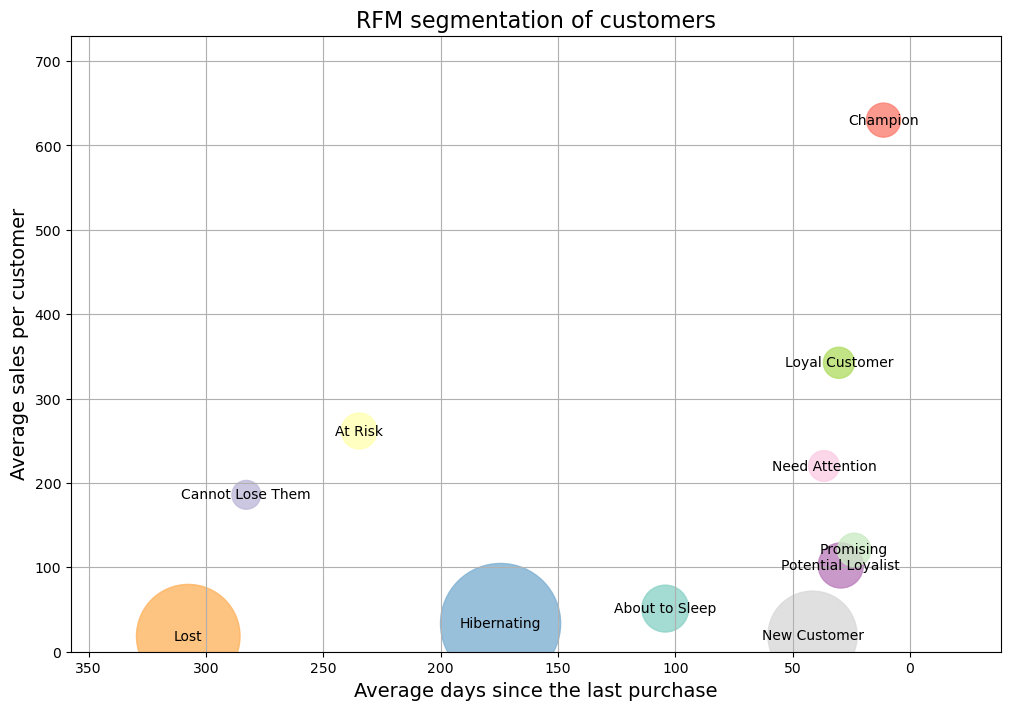

In [ ]:
segment_summary = df_rfm.groupby('Customer_Segment').agg(
    avg_days_since_purchase=('Recency', 'mean'),
    avg_sales_per_customer=('Monetary', 'mean'),
    customer_count=('Customer_ID', 'count')
).reset_index()

plt.figure(figsize=(12,8))
scatter = plt.scatter(
    segment_summary['avg_days_since_purchase'],
    segment_summary['avg_sales_per_customer'],
    s=segment_summary['customer_count'],
    c=sns.color_palette('Set3', len(segment_summary)),
    alpha=0.8
)

# Labeling the axes and title
plt.xlabel('Average days since the last purchase', fontsize=14)
plt.ylabel('Average sales per customer', fontsize=14)
plt.title('RFM segmentation of customers', fontsize=16)
plt.grid(True)

for i, text in enumerate(segment_summary['Customer_Segment']):
    plt.annotate(
        text,
        (segment_summary['avg_days_since_purchase'][i], segment_summary['avg_sales_per_customer'][i]),
        ha='center',
        va='center'
    )

plt.gca().invert_xaxis()

plt.xlim(segment_summary['avg_days_since_purchase'].max() + 50, segment_summary['avg_days_since_purchase'].min() - 50)
plt.ylim(0, segment_summary['avg_sales_per_customer'].max() + 100)

plt.show()


# **B. CV Analisis**


### **What is CV?**

**Coefficient of Variance (CV)** compares **the standard deviation (STD) for the total of customers with their average purchase**. This analysis is conducted to determine whether a customer's purchasing pattern is **consitent** or **unstable** over time.

#### **Coefficient of Variance (CV) Formula**

As it is mentioned earlier, the **Coevicient of Varience (CV)**  is calculated by dividing the **standard deviation (STD)** by the **average (mean)**.

$$
CV = \frac{\sigma}{\mu}
$$

Explanations:

- \(CV\) = Coefficient of Variance  
- ($\sigma$) = Standard Deviation  
- ($\mu$) = Mean (average)

#### CV Value Interpretation

| CV Score | Customer Category | Interpretations |
|--------|--------|-------------|
| CV < 0.5 | Stable | The customer's purchasing pattern is consistent and identical across each period. |
| 0.5 ≤ CV < 1 | Normal | The customer's purchasing pattern is still within a reasonable or normal range of variation. |
| CV ≥ 1 | Impulsive | The customer's purchasing pattern is highly inconsistent and unpredictable. |


## **1. Defining the CV**

### _**Creating new columns to calculate the CV**_

In [ ]:
## Creating data columns for each transaction
df["Basket_Size"] = df.groupby('Transaction_ID')["SKU"].transform('count')
df

,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,Recency,Frequency,Monetary,Basket_Size
0,2016-01-02,2547,1,X52,0EM7L,1.0,3.13,260,7,121.36,1
1,2016-01-02,822,2,2ML,68BRQ,1.0,5.46,333,3,20.40,1
2,2016-01-02,3686,3,0H2,CZUZX,1.0,6.35,299,15,405.44,1
3,2016-01-02,3719,4,0H2,549KK,1.0,5.59,302,10,420.72,1
4,2016-01-02,9200,5,0H2,K8EHH,1.0,6.88,267,2,18.01,1
...,...,...,...,...,...,...,...,...,...,...,...
131701,2016-07-04,20203,32900,IEV,FO112,3.0,6.46,58,9,270.60,7
131702,2016-07-04,20203,32900,N8U,I36F2,1.0,4.50,58,9,270.60,7
131703,2016-07-04,20203,32900,U5F,4X8P4,1.0,5.19,58,9,270.60,7
131704,2016-07-04,20203,32900,0H2,ZVTO4,1.0,4.57,58,9,270.60,7


In [ ]:
## Creating Aggregation per Customer ID
df['mean_basket'] = df.groupby("Customer_ID")["Basket_Size"].transform("mean")
df['std_basket'] = df.groupby("Customer_ID")["Basket_Size"].transform("std")
df

,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,Recency,Frequency,Monetary,Basket_Size,mean_basket,std_basket
0,2016-01-02,2547,1,X52,0EM7L,1.0,3.13,260,7,121.36,1,2.750000,1.000000
1,2016-01-02,822,2,2ML,68BRQ,1.0,5.46,333,3,20.40,1,2.200000,1.095445
2,2016-01-02,3686,3,0H2,CZUZX,1.0,6.35,299,15,405.44,1,6.000000,3.979540
3,2016-01-02,3719,4,0H2,549KK,1.0,5.59,302,10,420.72,1,13.510638,7.986054
4,2016-01-02,9200,5,0H2,K8EHH,1.0,6.88,267,2,18.01,1,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
131701,2016-07-04,20203,32900,IEV,FO112,3.0,6.46,58,9,270.60,7,5.702703,2.025735
131702,2016-07-04,20203,32900,N8U,I36F2,1.0,4.50,58,9,270.60,7,5.702703,2.025735
131703,2016-07-04,20203,32900,U5F,4X8P4,1.0,5.19,58,9,270.60,7,5.702703,2.025735
131704,2016-07-04,20203,32900,0H2,ZVTO4,1.0,4.57,58,9,270.60,7,5.702703,2.025735


## **2. Filtering Data**

In [ ]:
df_cv = df[["Customer_ID", "Frequency","mean_basket", "std_basket"]]

In [ ]:
# Calculating the CV Column
df_cv["CV"] = (
    df_cv["std_basket"] /
    df_cv["mean_basket"]
)

df_cv

,Customer_ID,Frequency,mean_basket,std_basket,CV
0,2547,7,2.750000,1.000000,0.363636
1,822,3,2.200000,1.095445,0.497930
2,3686,15,6.000000,3.979540,0.663257
3,3719,10,13.510638,7.986054,0.591094
4,9200,2,1.000000,0.000000,0.000000
...,...,...,...,...,...
131701,20203,9,5.702703,2.025735,0.355224
131702,20203,9,5.702703,2.025735,0.355224
131703,20203,9,5.702703,2.025735,0.355224
131704,20203,9,5.702703,2.025735,0.355224


In [ ]:
df_cv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131706 entries, 0 to 131705
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Customer_ID  131706 non-null  int64  
 1   Frequency    131706 non-null  int64  
 2   mean_basket  131706 non-null  float64
 3   std_basket   125405 non-null  float64
 4   CV           125405 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 5.0 MB


## **3. Analyze the Category**

In [ ]:
# Categorizing Customer Behavior Based on CV
def classify_behavior(row):
    if row["Frequency"] < 4:
        return "Uncertain(Low Data)"
    else:
        if row["CV"] < 0.5:
            return "Stabil"
        elif 0.5 <= row["CV"] < 1:
            return "Normal"
        elif row["CV"] >= 1:
            return "Impulsif"

df_cv["Customer_Behaviour"] = df_cv.apply(classify_behavior, axis=1)

df_cv

,Customer_ID,Frequency,mean_basket,std_basket,CV,Customer_Behaviour
0,2547,7,2.750000,1.000000,0.363636,Stabil
1,822,3,2.200000,1.095445,0.497930,Uncertain(Low Data)
2,3686,15,6.000000,3.979540,0.663257,Normal
3,3719,10,13.510638,7.986054,0.591094,Normal
4,9200,2,1.000000,0.000000,0.000000,Uncertain(Low Data)
...,...,...,...,...,...,...
131701,20203,9,5.702703,2.025735,0.355224,Stabil
131702,20203,9,5.702703,2.025735,0.355224,Stabil
131703,20203,9,5.702703,2.025735,0.355224,Stabil
131704,20203,9,5.702703,2.025735,0.355224,Stabil


In [ ]:
df_cv["Customer_Behaviour"].value_counts()

Customer_Behaviour
Uncertain(Low Data)    49664
Stabil                 48864
Normal                 33178
Name: count, dtype: int64

In [ ]:
# Removing duplicates
df_cv.drop_duplicates(inplace=True)
df_cv

,Customer_ID,Frequency,mean_basket,std_basket,CV,Customer_Behaviour
0,2547,7,2.750000,1.000000,0.363636,Stabil
1,822,3,2.200000,1.095445,0.497930,Uncertain(Low Data)
2,3686,15,6.000000,3.979540,0.663257,Normal
3,3719,10,13.510638,7.986054,0.591094,Normal
4,9200,2,1.000000,0.000000,0.000000,Uncertain(Low Data)
...,...,...,...,...,...,...
131632,14811,1,1.000000,NaN,NaN,Uncertain(Low Data)
131650,3232,1,2.000000,0.000000,0.000000,Uncertain(Low Data)
131652,5751,1,3.000000,0.000000,0.000000,Uncertain(Low Data)
131665,10765,1,1.000000,NaN,NaN,Uncertain(Low Data)


## **C. Merging RFM Segmentation with CV**


## **1. Visualizing**

### **Merge Data Frame**

In [ ]:
#merging data
df_customer_behavior =  pd.concat([df_rfm, df_cv.drop(columns=["Customer_ID", "Frequency"])], axis=1)
df_customer_behavior

,Customer_ID,Recency,Frequency,Monetary,r_score,f_score,m_score,rfm_score,Customer_Segment,mean_basket,std_basket,CV,Customer_Behaviour
0,2547,260,7,121.36,1,3,3,133,At Risk,2.750000,1.000000,0.363636,Stabil
1,822,333,3,20.40,1,2,1,121,Lost,2.200000,1.095445,0.497930,Uncertain(Low Data)
2,3686,299,15,405.44,1,5,4,154,Cannot Lose Them,6.000000,3.979540,0.663257,Normal
3,3719,302,10,420.72,1,4,4,144,Cannot Lose Them,13.510638,7.986054,0.591094,Normal
4,9200,267,2,18.01,1,1,1,111,Lost,1.000000,0.000000,0.000000,Uncertain(Low Data)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
131632,14811,181,1,26.54,2,1,1,211,Hibernating,1.000000,NaN,NaN,Uncertain(Low Data)
131650,3232,153,1,12.89,2,1,1,211,Hibernating,2.000000,0.000000,0.000000,Uncertain(Low Data)
131652,5751,181,1,59.59,2,1,2,212,Hibernating,3.000000,0.000000,0.000000,Uncertain(Low Data)
131665,10765,181,1,1.19,2,1,1,211,Hibernating,1.000000,NaN,NaN,Uncertain(Low Data)


In [ ]:
df_customer_behavior.to_csv("dataset_Porto.csv")

### **Stacked Bar**

In [ ]:
segment_behavior = pd.crosstab(
    df_customer_behavior["Customer_Segment"],
    df_customer_behavior["Customer_Behaviour"]
)

In [ ]:
segment_behavior_pct = segment_behavior.div(
    segment_behavior.sum(axis=1), axis=0
) * 100

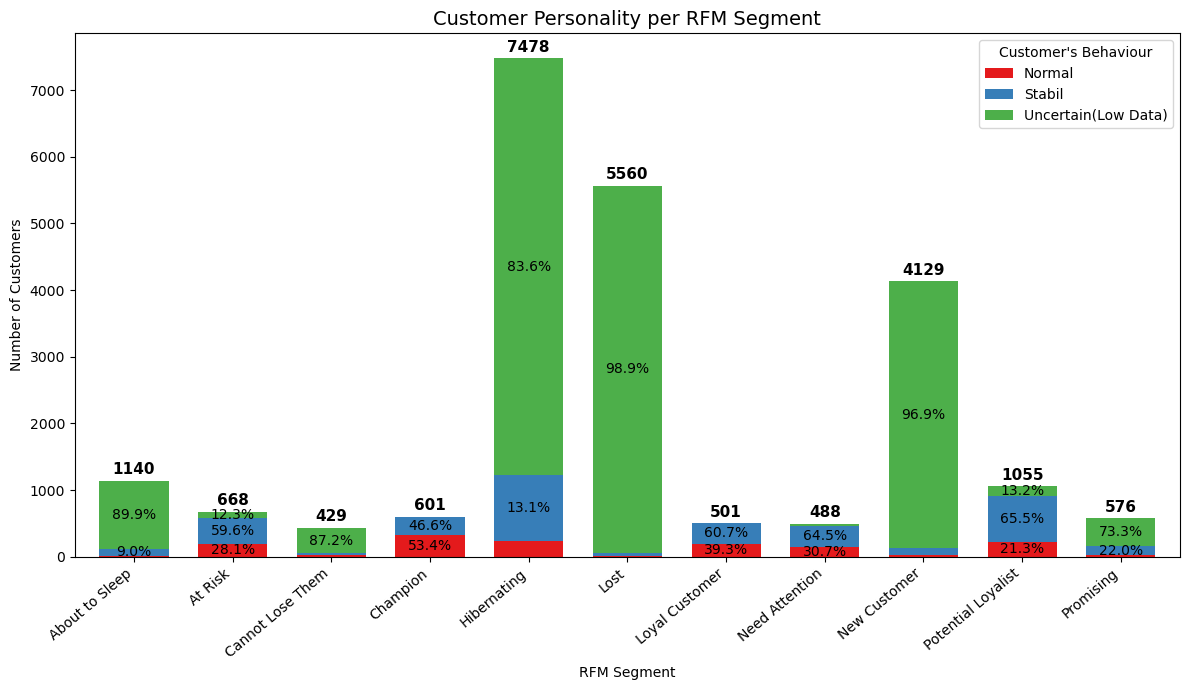

In [ ]:
# warna kategori
colors = sns.color_palette('Set1', len(segment_counts))   # impulsif, normal, stabil

# plot
fig, ax = plt.subplots(figsize=(12,7))

segment_behavior.plot(
    kind="bar",
    stacked=True,
    color=colors,
    width=0.7,
    ax=ax
)

# judul dan label
ax.set_title("Customer Personality per RFM Segment", fontsize=14)
ax.set_xlabel("RFM Segment")
ax.set_ylabel("Number of Customers")

plt.xticks(rotation=40, ha="right")

# LABEL PERSENTASE DALAM BAR
threshold = 8   # hanya tampilkan label jika >8%

for i, container in enumerate(ax.containers):

    labels = []

    for j, value in enumerate(container.datavalues):

        pct = segment_behavior_pct.iloc[j, i]

        if pct < threshold:
            labels.append("")
        else:
            labels.append(f"{pct:.1f}%")

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=10,
        color="black"
    )


# TOTAL CUSTOMER DI ATAS BAR
totals = segment_behavior.sum(axis=1)

for i, total in enumerate(totals):

    ax.text(
        i,
        total + 100,
        f"{int(total)}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )


plt.legend(title="Customer's Behaviour")
plt.tight_layout()
plt.show()

# **INSIGHT & CAMPAIGN**

# Champion Segment: Behaviour-Based Insight & Campaign Strategy

## Segment Overview

Total Champion Customers: **601**

| Behaviour | Percentage | Interpretation |
|---|---|---|
| Normal | 53.4% | Exploratory buying behaviour |
| Stabil | 46.6% | Habitual purchasing behaviour |

### Key Insight

Champion customers are **not homogeneous**.  
There are two distinct behavioural groups that drive revenue differently:

- **Habit-driven buyers (Stabil)** → predictable repeat purchase
- **Exploratory buyers (Normal)** → open to product discovery

Therefore, maximizing revenue from Champion customers requires **different strategies for each behaviour type**.

---

## Campaigns to Avoid

### Heavy Discount Campaigns

Reason:

Champion Stabil customers already have **high purchase intention**.

Providing discounts may lead to:

- Margin reduction

Risk:

Cost of discount **may exceed incremental revenue**.

---
# 1. Champion — Stabil Behaviour

## Behaviour Insight

Characteristics:

- High purchase frequency
- Relatively consistent basket size
- Often purchasing the same core products

Interpretation:

Customers in this group exhibit **strong purchasing habits**.  
Their revenue potential comes from **monetizing existing habits**, not from pushing new product exploration.

### Revenue Opportunity

The primary opportunity is:

- **Locking in repeat purchase**
- **Increasing basket efficiency**

---

## Recommended Campaigns

### 1. Replenishment Reminder

Example message:

> "Your coffee beans might be running low — reorder now."

Purpose:

- Reactivate the customer's **natural purchasing cycle**

Key insight from the discussion:

Habit reactivation is usually **more effective than immediate discounts**.

This is typically a **high ROI campaign**.

---

### 2. Functional Bundling

Type of bundling used here:

**Functional Bundling**

Example:

- Coffee beans + coffee filter
- Printer + ink cartridge

Reason:

These products are **naturally used together** with items the customer already purchases.

Goal:

- Increase **average basket size**

---

### 3. VIP Early Access

Example:

> "Exclusive early access for our most loyal customers."

Purpose:

- Strengthen **emotional loyalty**
- Reinforce **VIP customer status**

For Stabil behaviour, early access functions as **loyalty reinforcement**, not exploration.

---


# 2. Champion — Normal Behaviour

## Behaviour Insight

Characteristics:

- High spending
- High basket variability
- Frequently tries different products

Interpretation:

Customers in this group exhibit **exploratory buying behaviour**.

### Revenue Opportunity

The key opportunity is:

- **Cross-category expansion**
- **Product discovery**

---

## Recommended Campaigns

### 1. Discovery Bundling

Type of bundling:

**Discovery Bundling**

Example:

- Skincare starter kit
- Snack variety pack

Goal:

- Introduce new products within a curated bundle

Reason:

Champion Normal customers have **novelty-seeking behaviour**.

---

### 2. Product Recommendation / Cross-Sell

Example:

> "Customers who bought X also bought Y."

Purpose:

- Encourage product discovery
- Expand category purchase

Champion Normal customers are **highly responsive to product recommendations**.

---

### 3. Early Access Campaign

Example:

> "Be the first to try our newest collection."

Purpose:

- Trigger **curiosity-driven purchases**

Champion Normal customers are typically **more responsive to novelty and new product launches**.


---

# Strategic Summary

| Segment | Behaviour | Core Opportunity | Best Campaign |
|---|---|---|---|
| Champion | Stabil | Habit monetization | Replenishment reminder, Functional bundling |
| Champion | Normal | Product exploration | Discovery bundling, Cross-sell, Early access |

---

# Executive Insight

Champion customers represent **two distinct revenue engines**:

- **Habit-driven buyers** generate predictable revenue through replenishment and complementary product bundling.
- **Exploratory buyers** drive growth through product discovery and cross-category expansion.

Therefore, treating the Champion segment as a single group may **limit revenue potential**.  
Segmenting campaigns based on behavioural patterns allows businesses to **maximize customer lifetime value while minimizing unnecessary discount costs**.

## Need Attention Segment: Behaviour-Based Insight & Campaign Strategy

## Segment Overview

Total Need Attention Customers: **488**

| Behaviour | Percentage | Interpretation |
|---|---|---|
| Stabil | 64.5% | Previously consistent purchasing habit |
| Normal | 30.7% | Moderate variability in purchasing behaviour |

### Key Insight

Customers in the **Need Attention** segment previously showed engagement with the brand but have recently reduced their purchasing activity.

However, behaviour analysis reveals that many customers still retain **structured purchasing patterns**, especially those classified as **Stabil**.

This indicates that the main issue is **declining engagement rather than loss of product interest**.

Therefore, the primary objective for this segment is:

**Reactivating purchasing behaviour before customers transition into higher churn-risk segments (e.g., At Risk or Lost).**

---

## Campaigns to Avoid

### Large Discounts for Returning Customers

Example:

> 30% Off Promotion for Returning Customers

Problem:

Offering large discounts too early can lead to:

- decreased profit margins
- unnecessary promotional spending
- potential abuse (customers intentionally not shopping for a certain period to get the discount)

---

# 1. Need Attention — Stabil Behaviour

## Behaviour Insight

Characteristics:

- Previously consistent purchase behaviour
- Basket size relatively stable
- Purchase habit existed but has recently weakened

Interpretation:

These customers likely stopped purchasing due to **habit disruption**, not necessarily because they lost interest in the product.

Possible reasons include:

- forgetting to reorder
- temporary stock availability
- competing product distraction

### Revenue Opportunity

The opportunity lies in:

- **reactivating the existing purchase cycle**
- restoring **habit-based consumption**

This group is typically **high ROI for reactivation campaigns**.

---

## Recommended Campaign Flow (Reactivation Ladder)

### Stage 1 — Behavioural Reminder

Example:

> "Your usual skincare routine might be running low."

Purpose:

- Reactivate **existing purchase habit**

This approach leverages **contextual triggers**, which tend to perform better than generic reminders.

---

### Stage 2 — Personalized Product Reminder

Example:

> "Customers who purchased your favorite product also liked this."

Purpose:

- Increase **purchase relevance**
- Encourage product consideration
---

### Stage 3 — Comeback Discount

Example:

> "Welcome back — enjoy 10% off your next purchase."

Discount is introduced **only if previous engagement triggers fail**.

This strategy follows the **discount ladder principle**, minimizing unnecessary margin loss.

---



# 2. Need Attention — Normal Behaviour

## Behaviour Insight

Characteristics:

- Moderate basket variability
- Purchase patterns less predictable
- Engagement declining faster compared to Stabil behaviour

Interpretation:

Customers in this group may have **lost excitement or curiosity toward the product catalog**.

Their disengagement is often related to **reduced product novelty or perceived value**.

### Revenue Opportunity

The opportunity is to:

- **reignite curiosity**
- reintroduce **product relevance**

---

## Recommended Campaign Flow

### Stage 1 — Product Discovery Trigger

Example:

> "Check what's new this week."

Purpose:

- Stimulate curiosity
- Encourage browsing behaviour

---

### Stage 2 — Personalized Recommendation

Example:

> "Based on your last purchase, you might like this."

Purpose:

- Improve product relevance
- Increase purchase probability

---

### Stage 3 — Limited-Time Offer

Example:

> "48-hour comeback offer."

This stage introduces urgency to convert re-engaged customers.

---
# Strategic Summary

| Segment | Behaviour | Core Problem | Opportunity | Best Campaign |
|---|---|---|---|---|
| Need Attention | Stabil | Broken purchase habit | Habit reactivation | Replenishment reminder, targeted comeback discount |
| Need Attention | Normal | Declining engagement | Curiosity reactivation | Product discovery, personalized recommendations |

---

# Executive Insight

Need Attention customers should not immediately receive financial incentives.

Many customers in this segment still retain purchasing habits or product interest. Therefore, **behavioural triggers and contextual reminders should be prioritized before introducing discounts**.

By applying a **reactivation ladder approach**, businesses can:

- restore customer engagement
- minimize unnecessary discount spending
- protect profit margins while maintaining conversion potential.


# **Promising Segment: Behaviour-Based Insight & Suggestion**
## Segment Overview
Total Promising Customers: **576**
| Behaviour | Percentage |
|---|---|
| Stabil | 22% |
| Uncertain | 73.3% |

# Promising – Stable (22%)
## Insight
The customers in this segment demonstrate stable purchasing behavior, indicating that they have begun to develop a relatively consistent purchasing pattern, although their transaction frequency and spending value remain moderate. This suggests that these customers have the potential to become loyal customers if their engagement with the brand is maintained.

## Suggestion
1. Implement a loyalty program or membership system.
  
    A loyalty program can strengthen customer retention and encourage long-term engagement.
2. Provide personalized product recommendations.
    Recommendations based on their transaction history can increase the likelihood of additional purchases.

#Promising – Uncertain / Low Data (73.3%)

## Insight
The majority of customers in the Promising segment fall into the uncertain category, indicating that their transaction data is still limited and their purchasing patterns cannot yet be clearly identified.

## Suggestion
1. Offer promotions such as discounts or free shipping to encourage additional purchases.

    Additional transactions will help the company collect more behavioral data, allowing a clearer understanding of customer purchasing patterns.

2. Promote popular or best-selling products in marketing campaigns.

    Customers with limited purchasing data often do not yet have clear preferences, making popular products more appealing and easier to promote.

# **New Customer Segment: Behaviour-Based Insight & Suggestion**
## Segment Overview
Total New Customer Customers: **4,129**
| Behaviour | Percentage |
|---|---|
| Uncertain | 96.9% |

# New Customer – Uncertain (96.9%)
## Insight
Most customers in the New Customer segment fall into the uncertain category, indicating that they have only recently made their first purchase and have not yet developed a clear purchasing pattern.

## Suggestion
1. Launch a welcome campaign or onboarding program.
    
    Onboarding campaigns help introduce the brand to new customers and increase the likelihood of a second purchase.

2. Provide vouchers or discounts for the next purchase.
    
    Financial incentives can encourage repeat purchases during the early stages of the customer lifecycle.

3. Send follow-up communication such as thank-you emails or product recommendations.

    Post-purchase communication helps maintain engagement and build a positive initial relationship with the customer.

# **Potential Loyalist: Behaviour-Based Insight & Suggestion**
## Segment Overview
Total Potential Loyalist Customers: **1055**
| Behaviour | Percentage |
|---|---|
| Stable | 65.5% |
| Normal | 21.3% |
| Uncertain | 13.2% |

# Potential Loyalist – Stable (65.5%)
## Insight
The majority of customers in the Potential Loyalists segment exhibit stable purchasing behavior, indicating that they already have relatively consistent transaction patterns. This suggests strong potential for these customers to develop into loyal customers.

## Suggestion
1. Develop or expand loyalty reward programs.
  
    Customers with stable purchasing patterns are more likely to respond positively to reward-based incentives that encourage long-term engagement.

2. Provide exclusive access to promotions or new product launches.
    
    Exclusive offers can increase emotional attachment to the brand and encourage continued engagement.

3. Implement upselling or cross-selling strategies.

    Active customers are more likely to increase their spending when offered relevant additional products.

#Potential Loyalist – Normal (21.3%)

## Insight
Some customers in this segment display normal purchasing behavior, meaning they make purchases periodically but have not yet developed fully consistent buying patterns.

## Suggestion
1. Send personalized promotions based on transaction history.

    Relevant promotions can increase purchase frequency and help customers develop more consistent purchasing habits.

2. Offer limited-time promotions.

    Time-sensitive promotions can encourage quicker purchase decisions and increase transaction frequency.

#Potential Loyalist – Uncertain (13.2%)
## Insight
A small portion of customers in this segment still fall into the uncertain category, meaning their transaction data remains limited and their purchasing patterns cannot yet be clearly identified.

## Suggestion
1. Encourage additional purchases through light promotional incentives.

    Additional transactions will help the company better understand customer preferences.

2. Promote a variety of product categories in marketing campaigns.

    Exposure to different product categories may help identify customer interests and increase the likelihood of further purchases.

# Loyal Segment: Behaviour-Based Insight & Campaign Strategy

## Segment Overview

Total Loyal Customers: **501**

| Behaviour | Percentage | Interpretation |
|---|---|---|
| Stabil | 60.7% | Habitual repeat purchasing behaviour |
| Normal | 39.3% | Flexible purchasing behaviour|

### Key Insight

Loyal customers show two different behavioural purchasing patterns.

- Habit-driven buyers (Stabil) → repeat purchase patterns and consistent product choices

Flexible buyers (Normal) → loyal to the brand but still open to trying different products

Although both groups are loyal customers, their revenue drivers differ.

- Stabil behaviour generates predictable recurring revenue

- Normal behaviour generates category expansion opportunities

Therefore, maximizing revenue from Loyal customers requires **behaviour-specific marketing strategies rather than a single campaign approach.**

## Campaigns to Avoid

### Heavy Discount Campaigns

Heavy Discount Campaigns

Reason:

Loyal customers already demonstrate strong brand preference and repeat purchasing behaviour.

Providing frequent discounts may lead to:

Reduced profit margins

Discount dependency

Risk:

Customers may delay purchases until discounts are available, lowering long-term profitability.


# 1. Loyal — Stabil Behaviour

## Behaviour Insight

Characteristics:

- Consistent purchase frequency
- Repeat purchases of familiar products
- Predictable buying cycles

Interpretation:

Customers in this group demonstrate habitual purchasing behaviour.
Their purchase decisions are often driven by **routine consumption rather than exploration.**

### Revenue Opportunity

The main opportunity is to:

- **Strengthen repeat purchase cycles**
- **Increase basket efficiency through complementary products**

This group is typically **high ROI for reactivation campaigns**.

---

## Recommended Campaign Flow (Reactivation Ladder)

### Stage 1 — Replenishment Reminder

Example:

> "It's time to restock your favorite items — reorder now in just one click."

Purpose:

- **Reinforce the customer's natural purchasing cycle**
- **Reduce friction for repeat purchases**

This campaign helps maintain **consistent recurring revenue.**

---

### Stage 2 — Functional Bundling

Example:

- Shampoo + conditioner

- Coffee beans + coffee filter

- Printer + ink cartridge

Reason:

These products are **naturally used together with previously purchased items.**

Goal:

Increase **average order value**
---

### Stage 3 — Loyalty Status Reinforcement

Example:

> "Thank you for being one of our most loyal customers. Enjoy exclusive member benefits."

Purpose:

- Strengthen emotional loyalty

- Reinforce long-term brand attachment

For Stabil behaviour, loyalty recognition helps **maintain habitual purchasing patterns.**
---



# 2. Loyal — Normal Behaviour

## Behaviour Insight

Characteristics:

- Moderate to high purchase frequency
- Occasionally explores new products
- Basket composition varies between purchases

Interpretation:

Customers in this group remain loyal to the brand but **show greater openness to product variety.**

Their purchasing behaviour combines **brand loyalty with mild exploratory behaviour.**

### Revenue Opportunity

The opportunity is to:

- **Encouraging cross-category purchases**
- **Expanding product adoption**

---

## Recommended Campaign Flow

### Stage 1 — Cross-Sell Recommendation

Example:

> "Customers who purchased this item also enjoyed these products."

Purpose:

- Introduce complementary products
- Increase basket diversity

---

### Stage 2 — Curated Product Bundles

Type of bundling:

**Exploration Bundling**

Example:

- Skincare routine kit
- Coffee tasting bundle
- Healthy snack assortment

Goal:

Encourage customers to explore related product categories

---

### Stage 3 — Early Access to New Products

Example:

> "Be the first to discover our latest arrivals."

Purpose:

- **Encourage curiosity-driven purchases**

Increase engagement with new product launches

Loyal customers with Normal behaviour **are more receptive to product discovery campaigns.**

---
# Strategic Summary

| Segment | Behaviour | Core Opportunity                           | Best Campaign                                            |
| ------- | --------- | ------------------------------------------ | -------------------------------------------------------- |
| Loyal   | Stabil    | Strengthening repeat purchase habits       | Replenishment reminder, Functional bundling              |
| Loyal   | Normal    | Product exploration and category expansion | Cross-sell recommendation, Curated bundles, Early access |


# Executive Insight

Loyal customers represent a critical segment for sustained revenue growth, but their purchasing behaviour is not uniform.

Stabil buyers generate predictable revenue through habitual repeat purchases.

Normal buyers contribute to revenue expansion through product exploration and category diversification.

Treating Loyal customers as a single homogeneous group may limit marketing effectiveness.
By aligning campaigns with behavioural patterns, businesses can increase customer lifetime value while maintaining strong customer engagement.

# At Risk Segment: Behaviour-Based Insight & Campaign Strategy

## Segment Overview

Total Loyal Customers: **668**

| Behaviour | Percentage | Interpretation                                          |
| --------- | ---------- | ------------------------------------------------------- |
| Stabil    | ~60%       | Previously habitual buyers with declining engagement    |
| Normal    | ~28%       | Previously active but inconsistent purchasing behaviour |
| Uncertain | ~12%       | Limited recent transaction data                         |

### Key Insight

At Risk customers represent **previously valuable customers whose engagement has declined significantly.**

Two behavioural patterns can be observed:

- **Stabil buyers** → previously habitual purchasers who stopped buying recently

- **Normal buyers** → previously active but with more flexible purchasing behaviour

Although both groups were historically valuable customers, they now show **high churn risk due to prolonged inactivity.**

This means the revenue opportunity lies in **recovering lost engagement before these customers transition into the lost customer segment**.

## Campaigns to Avoid

### Generic Mass Promotions

Reason:

At Risk customers require **targeted engagement rather than broad promotional campaigns.**

Generic promotions may fail because:

The core issue is declining engagement, not price sensitivity.

Risk:

Mass campaigns may lead to **low conversion rates and inefficient marketing spending.**


# 1. At Risk — Stabil Behaviour

## Behaviour Insight

Characteristics:

- Previously consistent purchase behaviour
- Established purchasing habits in the past
- Long inactivity period despite strong purchase history

Interpretation:

Customers in this group previously demonstrated strong purchasing routines, but those routines have been disrupted.

Their disengagement may be caused by:

- competing brands
- shifting customer needs
- forgotten purchasing cycles


### Revenue Opportunity

The main opportunity is to:

- **Reactivating previous purchasing habits**
- **Recovering predictable revenue streams**

--

## Recommended Campaign Flow

### Stage 1 — Win-Back Reminder

Example:

> "It's been a while since your last purchase — here's a special offer to welcome you back."

Purpose:

- **Remind customers of their previous relationship with the brand**

---

### Stage 2 — Replenishment Reactivation

Example:

> "Your favorite items might be running low — reorder today with a special comeback reward."

Purpose:

- **Restore previous purchasing routines**

---

### Stage 3 — Personalized Loyalty Incentive

Example:

> "Because you were one of our valued customers, enjoy 20% off your next order"

Purpose:

- **Reinforce the customer-brand relationship**

---


# 2. At Risk — Normal Behaviour

## Behaviour Insight

Characteristics:

- Previously active buyers
- Moderate purchase frequency
- Flexible product choices

Interpretation:

Customers in this group previously engaged with the brand but showed **less consistent purchasing patterns compared to Stabil buyers.**

Their disengagement may be related to:

- reduced interest in product offerings
- lack of new product appeal

### Revenue Opportunity

The opportunity is to:

- **Reintroducing product interest**
- **Stimulating curiosity-driven purchases**

---

## Recommended Campaign Flow

### Stage 1 — Personalized Product Recommendation

Example:

> "Based on your previous purchases, we think you'll love these products."

Purpose:

- Reignite interest through relevant product suggestions


---

### Stage 2 — Comeback Promotion

Type of bundling:

**Exploration Bundling**

Example:

"We miss you! Enjoy 15% off your next purchase."
Goal:

Purpose:

Encourage immediate re-engagement

---

### Stage 3 — New Product Discovery Campaign

Example:

> "Discover what's new — explore our latest collection."

Purpose:

- **Encourage product rediscovery**

Increase engagement with new product launches



---
# Strategic Summary

| Segment | Behaviour | Core Opportunity            | Best Campaign                                 |
| ------- | --------- | --------------------------- | --------------------------------------------- |
| At Risk | Stabil    | Recover habitual purchasing | Win-back reminder, Replenishment reactivation |
| At Risk | Normal    | Reignite product interest   | Product recommendation, Comeback promotion    |


# Executive Insight

At Risk customers represent **a significant revenue recovery opportunity** because they were previously active and high-value customers.

- **Stabil buyers** can be reactivated by restoring previous purchasing routines.

- **Normal buyers** can be re-engaged through personalized product discovery and targeted incentives.

Recovering this segment is **often more cost-effective than acquiring new customers**, making it a critical focus for retention strategies.

# Hibernating Segment: Behaviour-Based Insight & Campaign Strategy

## Segment Overview

Total Loyal Customers: **7,478**

| Behaviour | Percentage | Interpretation                      |
| --------- | ---------- | ----------------------------------- |
| Uncertain | ~84%       | Very limited transaction history    |
| Stabil    | ~13%       | Previously occasional repeat buyers |
| Normal    | ~3%        | Sporadic purchasing behaviour       |
                        |

### Key Insight

Hibernating customers represent the largest but least engaged segment in the customer base.

Most customers in this segment have very limited purchase history, which indicates that many of them may have made only one or two purchases before becoming inactive.

This makes the segment highly heterogeneous, with varying levels of past engagement.

## Campaigns to Avoid

### High-Cost Personalized Campaigns

Reason:

Many customers in this segment have **very low historical spending.**

Providing expensive personalized campaigns may lead to **low return on investment.**

Risk:

Marketing cost may **exceed potential revenue recovery.**


# 1. Hibernating — Stabil Behaviour

## Behaviour Insight

Characteristics:

- reviously occasional repeat buyers
- Some purchasing consistency in the past
- Long inactivity period

Interpretation:

These customers had **some level of purchasing habit**, but their engagement weakened over time.

### Revenue Opportunity

The main opportunity is to:

- **Reactivating dormant purchasing habits**


## Recommended Campaign Flow

### Stage 1 — Reactivation Reminder

Example:

> "It's been a while since your last visit — check out what's new."

Purpose:

- **Reintroduce the brand to inactive customers.**

---

### Stage 2 — Comeback Incentive

Example:

> "Welcome back! Enjoy free shipping on your next order."

Purpose:

- **Reduce friction for returning customers.**

---


# 2. Hibernating — Normal/ Uncertain Behaviour

## Behaviour Insight

Characteristics:

- Very low purchase frequency
- Limited customer engagement
- Minimal purchase history

Interpretation:

Customers in this group likely made **one-time** purchases and never developed a relationship with the brand.


### Revenue Opportunity

The opportunity is to:

- **Low-cost reactivation attempts**
- **Testing whether customers are still reachable**

---

## Recommended Campaign Flow

### Stage 1 — Broad Reactivation Campaign

Example:

> "We've missed you! Here's a special offer for your next purchase."

Purpose:

- Trigger a **return visit**


---

### Stage 2 — Entry-Level Promotion


Example:

"Discover our best-selling products with this limited-time offer."


Purpose:

Lower the barrier to re-engagement.

---


# Strategic Summary

| Segment     | Behaviour        | Core Opportunity          | Best Campaign                                      |
| ----------- | ---------------- | ------------------------- | -------------------------------------------------- |
| Hibernating | Stabil           | Reactivate dormant habits | Reactivation reminder, Comeback incentive          |
| Hibernating | Uncertain/Normal | Low-cost re-engagement    | Broad reactivation campaign, Entry-level promotion |



# Executive Insight

Hibernating customers represent **a large inactive portion of the customer base**, but their revenue contribution is currently minimal due to extremely low engagement.

While most customers in this segment have limited purchase history, targeted low-cost reactivation campaigns can still unlock **incremental revenue opportunities.**

Because of the segment's size, even **small improvements in reactivation rates can lead to meaningful increases in total transactions.**

# **About to Sleep Segment: Behaviour-Based Insight & Suggestion**
## Segment Overview
Total About  Customers: **1,140**
| Behaviour | Insight | Campaign Strategy |
|---|---|---|
| Stable (90%) | Customers who used to have a regular shopping schedule, but have now lost their pattern | "Back to Routine" Reminder: Send automated reminders based on their previous shopping cycle (e.g., "Is it time to restock your favorite products?") |
| Uncertain (89.9%) | Dominant. Customers with inconsistent behavioral data or minimal engagement after their first purchase. | "The Hook" Offer: Offer a low-barrier offer like a flat discount or a free product with a low minimum spend to encourage repeat purchases and build behavioral data. |
| Normal (1.1%) | New customers or occasional shoppers who stopped. | "New Arrivals" Blast: Simply send updates on the latest products or current trends to see if they're still interested. |

# **Lost Segment: Behaviour-Based Insight & Suggestion**
## Segment Overview
Total About  Customers: **5,560**
| Behaviour | Insight | Campaign Strategy |
|---|---|---|
| Stable (0.7%) | Former loyal customers who have completely churn. This is a huge loss. | Reactivation Call/Survey: Give your most aggressive "Welcome Back" offer (e.g., 50% voucher) to win them back from competitors |
| Uncertain (98.9%) | Very Dominant. Almost all of this segment consists of accounts with very limited data. | Low-Cost Retargeting: Don't use expensive SMS/WhatsApp blasts. Use social media ads (FB/IG) to remind customers generally. If there is no interaction, this database can be archived. |
| Normal (0.4%) | Sporadic lost customers | Newsletters: Only add them to your monthly promotional newsletter distribution list |

# **Cannot Lose Them Segment: Behaviour-Based Insight & Suggestion**
## Segment Overview
Total About  Customers: **429**
| Behaviour | Insight | Campaign Strategy |
|---|---|---|
| Stable (7.2%) | Premium customers who were once very loyal and predictable. | VIP Concierge: Don't send mass messages. Contact your Customer Service/Manager personally to offer unconditional appreciation or rewards. |
| Uncertain (87.2%) | Dominant. Customers who have made large purchases (perhaps for projects or large inventory purchases) but whose data is incomplete. | Membership Upgrade: Offer them free VIP/Gold Member status if they make a repeat purchase. The goal is to lock them into the loyalty program to better capture their data. |
| Normal (5.6%) | Large customers who spend irregularly. | Exclusive Early Access: Provide early access to new collections or promotions before they are announced to the public.

## **Key Insights (The Big Picture)**
1. Dominance of "Blind" Data (Uncertain/Low Data):
Almost all critical segments (Lost 98.9%, About to Sleep 89.9%, Cannot Lose Them 87.2%) are dominated by the Uncertain category. This is a "yellow light" for businesses. It means you have thousands of customer databases, but you don't really "know" who they are or what their shopping preferences are.

2. High-Value Customer Leakage:
The Cannot Lose Them segment (429 people) is the largest asset on the verge of exit. Although smaller in number than the Lost segment, their monetary value is much higher. Failure to convert them back will directly impact significantly decreased profitability.

3. Potential "Sleeping Giant" in the Lost Segment:
There are 5,560 customers in the Lost segment. Despite the low data (Uncertain), this is a very large prospect pool. If you can reactivate just 5-10% of them, your revenue growth will skyrocket without having to find new customers from scratch.

## Next Steps (Action Plan)
1. VIP Rescue (Focus: Cannot Lose Them)
Action: Conduct manual outreach or send highly exclusive personalized messages.

- Target: Focus on those in Stable and Normal status first because they are more predictable.

- Offer: "Direct Loyalty Rewards" (not just shopping discounts) to reward their past high spending history.

2. Data Validation (Focus: About to Sleep)
Action: Send interactive campaigns such as "Surveys with Voucher Prizes."

- Goal: Change Uncertain status to Normal/Stable. By completing surveys (product interest, favorite categories), you gain data to personalize future promotions.

3. Cost Efficiency (Focus: Lost)
Action: Don't waste a large advertising budget on all 5,560 people.

- Method: Conduct A/B testing on a small sample (e.g., 500 people). If the response is low, it's better to shift your marketing budget to the Potential Loyalist or Champion segments, which have healthier data.

## Strategic Recommendation
- "Building a Customer Data Infrastructure (CDP Simplification)"

- Given the high number of Uncertains, my main suggestion is to improve the data collection system at the point of sale (POS/E-commerce).

- Digital Identity: Ensure every transaction is linked to a validated WhatsApp number or email address.

- Profiling Incentives: Offer an additional 5% discount if customers complete their profile information (Date of Birth, Favorite Product Categories).

- CRM Automation: Use an automation tool that automatically sends a "Check-in" message 30 days after their last purchase to prevent customers from falling into the About to Sleep segment.

